In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

μ = -0.1 -> Equilibrios: [(0, -0.397635364383525 - 0.397635364383525*I), (0, 0.397635364383525 + 0.397635364383525*I), (0, -I*(0.397635364383525 + 0.397635364383525*I)), (0, I*(0.397635364383525 + 0.397635364383525*I))]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\917283565.py:4: RuntimeWarning: overflow encountered in scalar power
  dYdt = μ - y**4
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\917283565.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


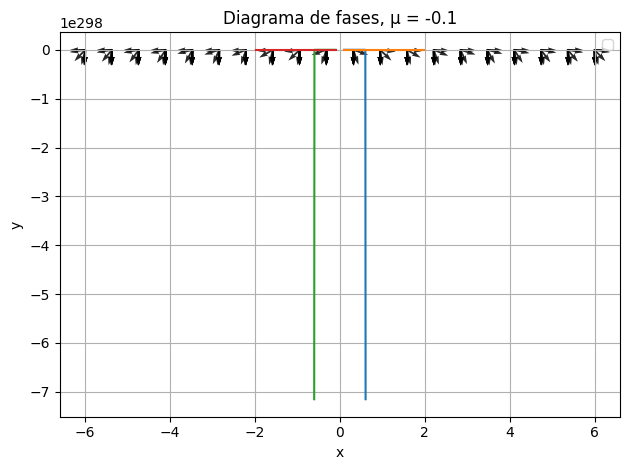

μ = 0 -> Equilibrios: [(0, 0), (0, 0), (0, 0), (0, 0)]


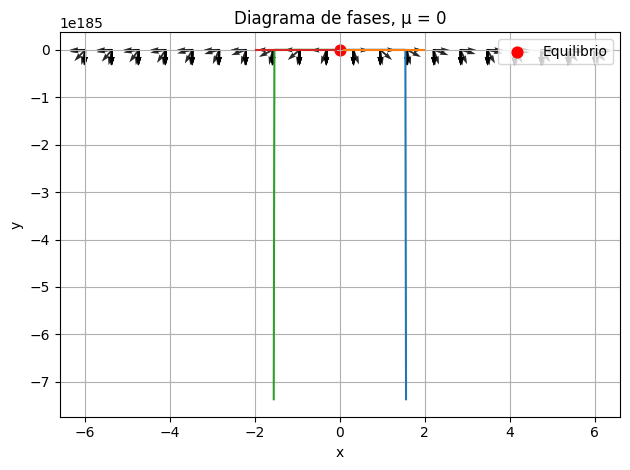

μ = 0.5 -> Equilibrios: [(0, -0.840896415253715), (0, 0.840896415253715), (0, -0.840896415253715*I), (0, 0.840896415253715*I)]


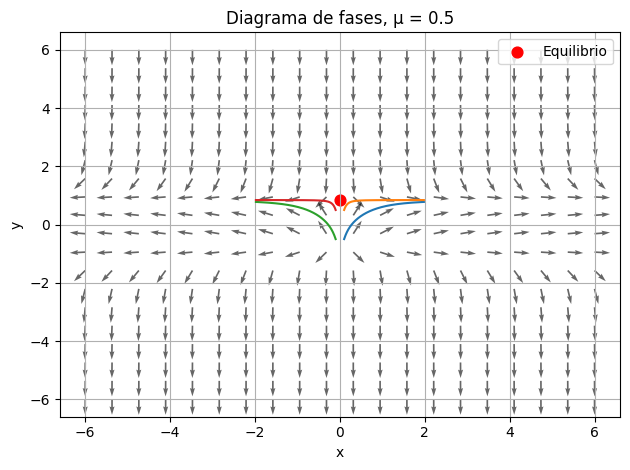

In [2]:
def sistema(estado, μ):
    x, y = estado
    dXdt = x 
    dYdt = μ - y**4
    return np.array([dXdt, dYdt])

def euler(x0, y0, μ, t0, tf, h):
    num_pasos = int((tf-t0)/h)
    t = np.linspace(t0, tf, num_pasos+1)
    
    X = np.zeros(num_pasos+1)
    X[0] = x0
    Y = np.zeros(num_pasos+1)
    Y[0] = y0 
    
    for i in range(num_pasos):
        estado = np.array([X[i], Y[i]])
        pendiente = sistema(estado, μ)
        
        X[i+1] = X[i] + h * pendiente[0]
        Y[i+1] = Y[i] + h * pendiente[1]
        
    return t, X, Y

mus = [-0.1, 0, 0.5]
condiciones_iniciales = [(0.1, -0.5), (0.1, 0.5), (-0.1,-0.5), (-0.1, 0.5)]

for μ in mus:
    
    # Equilibrio
    X_sym, Y_sym = sp.symbols('X Y')
    μ_sym = sp.symbols('μ')

    eq1 = X_sym
    eq2 = μ_sym - Y_sym**4

    equilibrios = sp.solve((eq1, eq2), (X_sym, Y_sym))
    valores = {μ_sym: μ}
    equilibrios_num = [(x.subs(valores), y.subs(valores)) for x, y in equilibrios]
    print(f"μ = {μ} -> Equilibrios: {equilibrios_num}")
    
    
    # Campo vectorial
    x_vals = np.linspace(-6, 6, 20)
    y_vals = np.linspace(-6, 6, 20)
    X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

    U = X_grid
    V = μ - Y_grid**4

    norma = np.sqrt(U**2 + V**2)
    norma[norma == 0] = 1

    U_norm = U / norma
    V_norm = V / norma
    
    # Gráfico
    
    plt.quiver(X_grid, Y_grid, U_norm, V_norm, alpha=0.6)
        
    # Trayectorias
    for x0, y0 in condiciones_iniciales:
        t, x, y = euler(x0, y0, μ, 0, 3, 0.01)
        plt.plot(x, y)
        
    if μ > 0:
        y_eq = μ**0.25
        plt.scatter(0, y_eq, color='red', marker='o', s=60, label='Equilibrio')
    elif μ == 0:
        plt.scatter(0, 0, color='red', marker='o', s=60, label='Equilibrio')
        
        
    plt.title(f'Diagrama de fases, μ = {μ}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

μ = -0.5 -> Equilibrios: [(0, -0.594603557501361 - 0.594603557501361*I), (0, 0.594603557501361 + 0.594603557501361*I), (0, -I*(0.594603557501361 + 0.594603557501361*I)), (0, I*(0.594603557501361 + 0.594603557501361*I))]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\1707471654.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


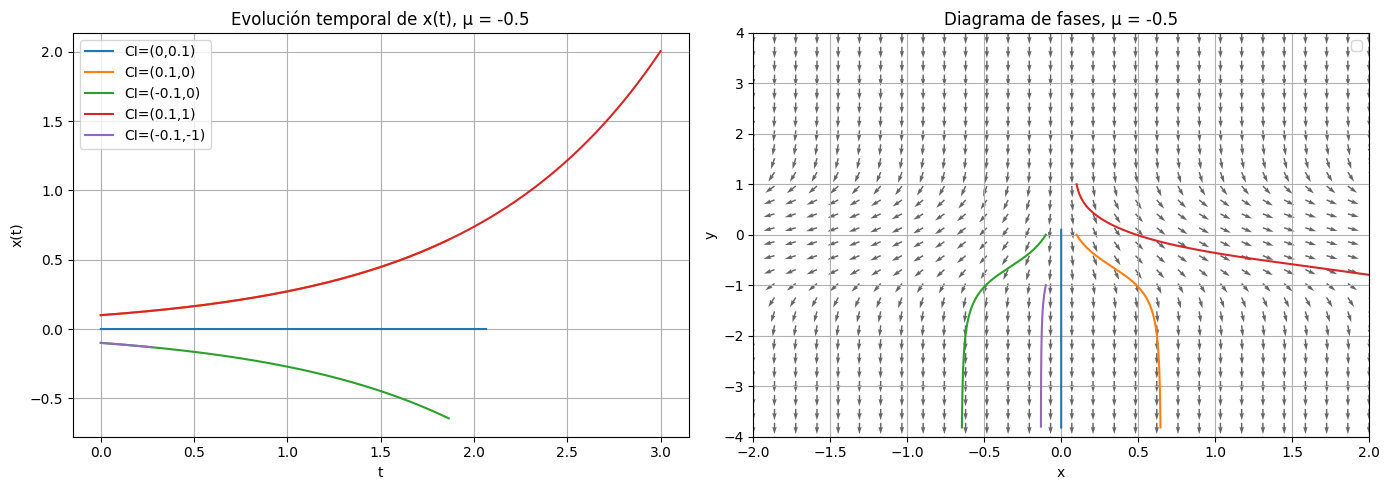

μ = 0 -> Equilibrios: [(0, 0), (0, 0), (0, 0), (0, 0)]


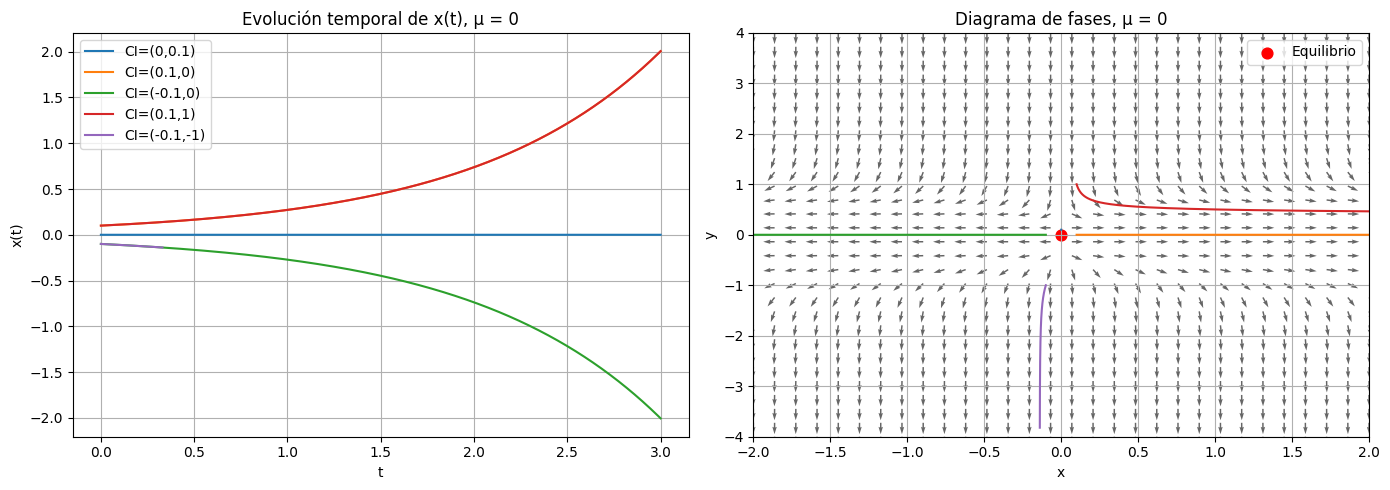

μ = 0.5 -> Equilibrios: [(0, -0.840896415253715), (0, 0.840896415253715), (0, -0.840896415253715*I), (0, 0.840896415253715*I)]


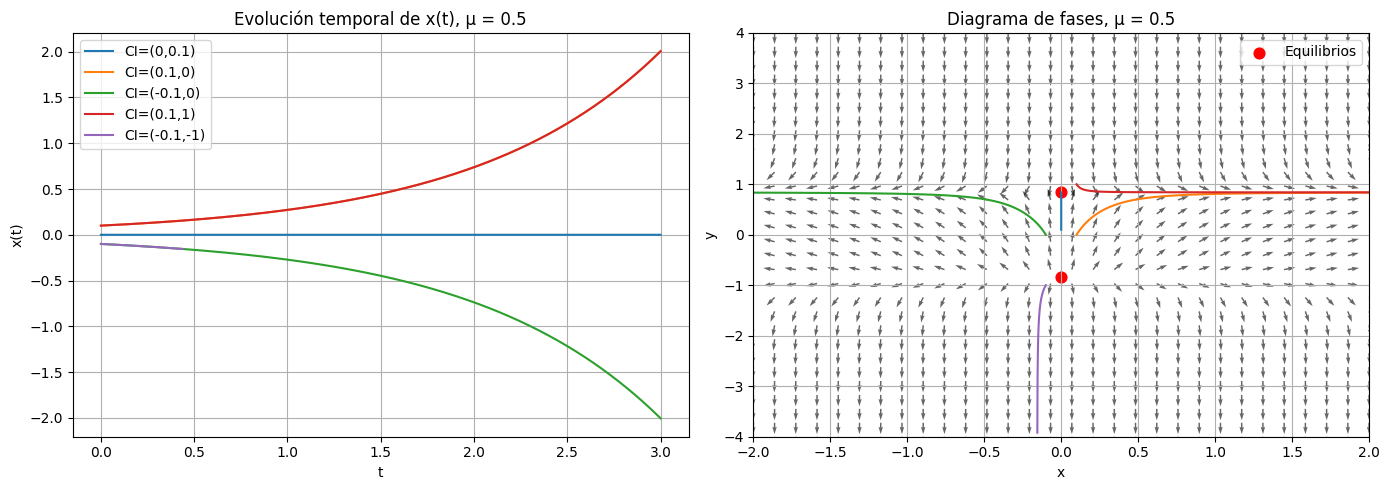

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sistema(estado, μ):
    x, y = estado
    dXdt = x
    dYdt = μ - y**4
    return np.array([dXdt, dYdt])

def euler(x0, y0, μ, t0, tf, h, umbral=5):
    num_pasos = int((tf - t0) / h)

    t = [t0]
    X = [x0]
    Y = [y0]

    x, y = x0, y0
    tiempo = t0

    for _ in range(num_pasos):
        pendiente = sistema(np.array([x, y]), μ)

        x = x + h * pendiente[0]
        y = y + h * pendiente[1]
        tiempo = tiempo + h

        if not np.isfinite(x) or not np.isfinite(y):
            break

        if abs(x) > umbral or abs(y) > umbral:
            break

        t.append(tiempo)
        X.append(x)
        Y.append(y)

    return np.array(t), np.array(X), np.array(Y)

mus = [-0.5, 0, 0.5]
condiciones_iniciales = [(0,0.1), (0.1, 0), (-0.1, 0), (0.1, 1), (-0.1, -1)]

for μ in mus:
    # Equilibrio
    X_sym, Y_sym = sp.symbols('X Y')
    μ_sym = sp.symbols('μ')

    eq1 = X_sym
    eq2 = μ_sym - Y_sym**4

    equilibrios = sp.solve((eq1, eq2), (X_sym, Y_sym))
    valores = {μ_sym: μ}
    equilibrios_num = [(x.subs(valores), y.subs(valores)) for x, y in equilibrios]
    print(f"μ = {μ} -> Equilibrios: {equilibrios_num}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Campo vectorial
    x_vals = np.linspace(-2, 2, 30)
    y_vals = np.linspace(-4, 4, 30)
    X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

    U = X_grid
    V = μ - Y_grid**4

    norma = np.sqrt(U**2 + V**2)
    norma[norma == 0] = 1

    U_norm = U / norma
    V_norm = V / norma

    axes[1].quiver(X_grid, Y_grid, U_norm, V_norm, alpha=0.6)

    # Trayectorias
    for x0, y0 in condiciones_iniciales:
        t, x, y = euler(x0, y0, μ, 0, 3, 0.001, umbral=4)

        axes[0].plot(t, x, label=f'CI=({x0},{y0})')
        axes[1].plot(x, y)

    # Equilibrios
    if μ == 0:
        axes[1].scatter(0, 0, color='red', s=60, label='Equilibrio')
    elif μ > 0:
        y_eq = μ**0.25
        axes[1].scatter(0, y_eq, color='red', s=60, label='Equilibrios')
        axes[1].scatter(0, -y_eq, color='red', s=60)

    axes[0].set_title(f'Evolución temporal de x(t), μ = {μ}')
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('x(t)')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_title(f'Diagrama de fases, μ = {μ}')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].set_xlim(-2, 2)
    axes[1].set_ylim(-4, 4)
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

μ = -0.5 -> Equilibrios: [(0, 0), (0.250000000000000, 0)]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\1095481594.py:3: RuntimeWarning: overflow encountered in scalar power
  dXdt = x**2 - x * μ**2
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\1095481594.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  dXdt = x**2 - x * μ**2


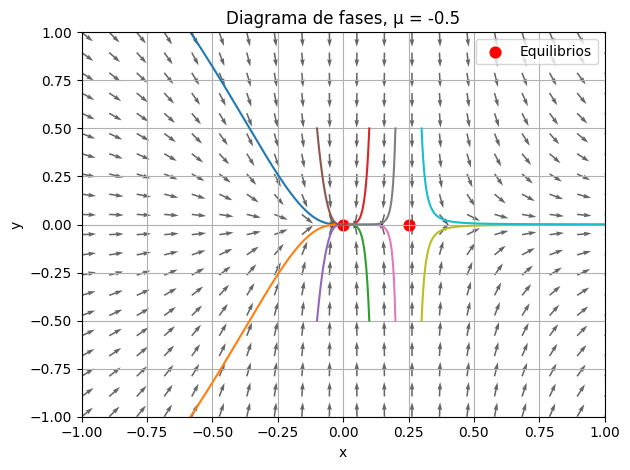

μ = 0 -> Equilibrios: [(0, 0), (0, 0)]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\1095481594.py:3: RuntimeWarning: invalid value encountered in scalar multiply
  dXdt = x**2 - x * μ**2


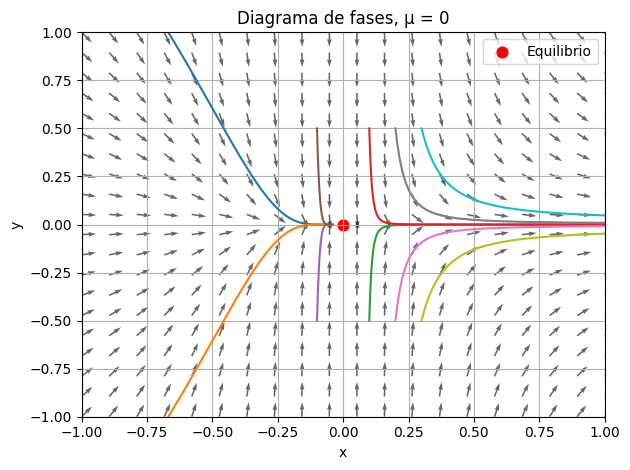

μ = 0.5 -> Equilibrios: [(0, 0), (0.250000000000000, 0)]


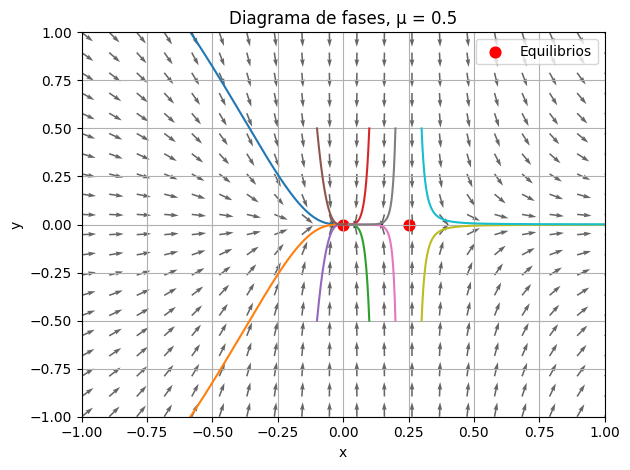

In [ ]:
def sistema(estado, μ):
    x, y = estado
    dXdt = x**2 - x * μ**2
    dYdt = -y
    return np.array([dXdt, dYdt])

def euler(x0, y0, μ, t0, tf, h):
    num_pasos = int((tf-t0)/h)
    t = np.linspace(t0, tf, num_pasos+1)
    
    X = np.zeros(num_pasos+1)
    X[0] = x0
    Y = np.zeros(num_pasos+1)
    Y[0] = y0 
    
    for i in range(num_pasos):
        estado = np.array([X[i], Y[i]])
        pendiente = sistema(estado, μ)
        
        X[i+1] = X[i] + h * pendiente[0]
        Y[i+1] = Y[i] + h * pendiente[1]
        
    return t, X, Y

mus = [-0.5, 0, 0.5]
condiciones_iniciales = [(0.1, -0.5), (0.1, 0.5), (-0.1,-0.5), (-0.1, 0.5),(0.2,-0.5),(0.2,0.5),(0.3,-0.5),(0.3,0.5)]

for μ in mus:
    
    # Equilibrio
    X_sym, Y_sym = sp.symbols('X Y')
    μ_sym = sp.symbols('μ')

    eq1 = X_sym**2 - X_sym * μ_sym**2
    eq2 = -Y_sym

    equilibrios = sp.solve((eq1, eq2), (X_sym, Y_sym))
    valores = {μ_sym: μ}
    equilibrios_num = [(x.subs(valores), y.subs(valores)) for x, y in equilibrios]
    print(f"μ = {μ} -> Equilibrios: {equilibrios_num}")
    
    
    # Campo vectorial
    x_vals = np.linspace(-1, 1, 20)
    y_vals = np.linspace(-1, 1, 20)
    X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

    U = X_grid**2 - X_grid * μ**2
    V = -Y_grid

    norma = np.sqrt(U**2 + V**2)
    norma[norma == 0] = 1

    U_norm = U / norma
    V_norm = V / norma
    
    # Gráfico
    
    plt.quiver(X_grid, Y_grid, U_norm, V_norm, alpha=0.6)
        
    # Trayectorias
    for x0, y0 in condiciones_iniciales:
        t, x, y = euler(x0, y0, μ, 0, 15, 0.01)
        plt.plot(x, y)
    
    # Equilibrios
    if μ == 0:
        plt.scatter(0, 0, color='red', s=60, label='Equilibrio')
    elif μ != 0:
        plt.scatter(0.25, 0, color='red', s=60, label='Equilibrios')
        plt.scatter(0, 0, color='red', s=60)
        
    plt.title(f'Diagrama de fases, μ = {μ}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    plt.xlim(-1,1)
    plt.ylim(-1,1)
    
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

mu = -0.5 -> Equilibrios: []


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\2156227989.py:3: RuntimeWarning: overflow encountered in scalar power
  dXdt = -x**4 + 5*μ*x**2 - 4*μ**2
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\2156227989.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


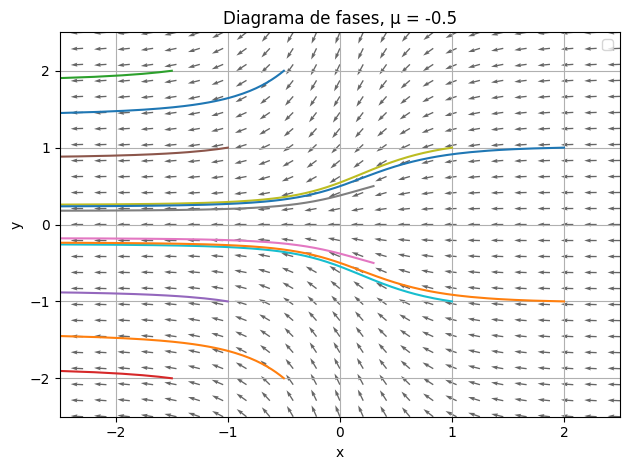

mu = 0 -> Equilibrios: [(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0.0, 0.0)]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\2156227989.py:3: RuntimeWarning: invalid value encountered in scalar multiply
  dXdt = -x**4 + 5*μ*x**2 - 4*μ**2


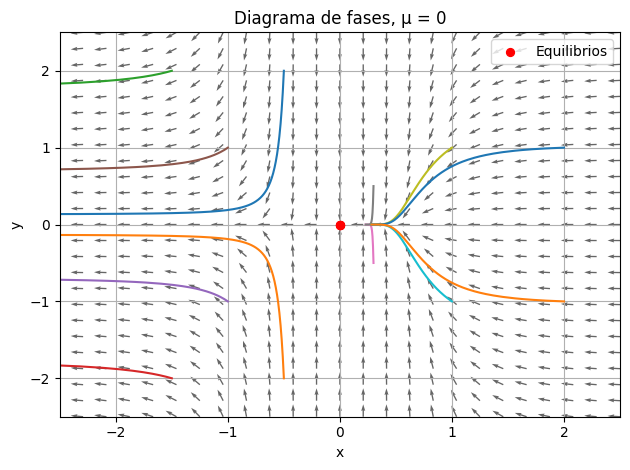

mu = 0.5 -> Equilibrios: [(-1.4142135623730951, 0.0), (-0.7071067811865476, 0.0), (0.7071067811865476, 0.0), (1.4142135623730951, 0.0)]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11312\2156227989.py:3: RuntimeWarning: invalid value encountered in scalar add
  dXdt = -x**4 + 5*μ*x**2 - 4*μ**2


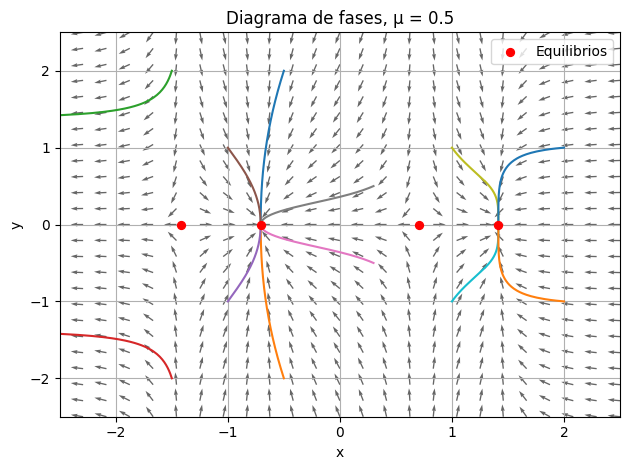

mu = 1.25 -> Equilibrios: [(-2.23606797749979, 0.0), (-1.118033988749895, 0.0), (1.118033988749895, 0.0), (2.23606797749979, 0.0)]


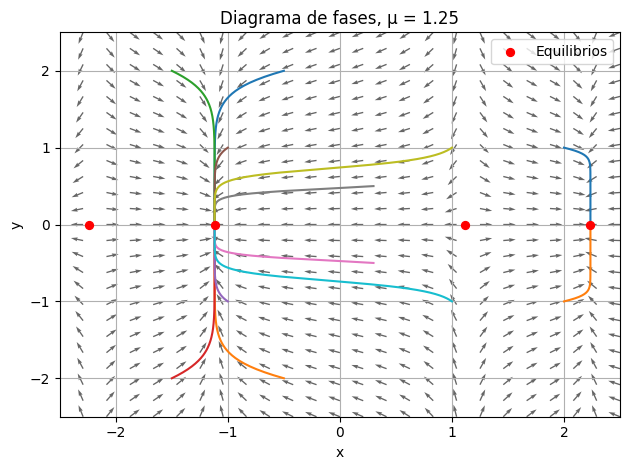

In [31]:
def sistema(estado, μ):
    x, y = estado
    dXdt = -x**4 + 5*μ*x**2 - 4*μ**2
    dYdt = -y
    return np.array([dXdt, dYdt])

def euler(x0, y0, μ, t0, tf, h):
    num_pasos = int((tf-t0)/h)
    t = np.linspace(t0, tf, num_pasos+1)
    
    X = np.zeros(num_pasos+1)
    X[0] = x0
    Y = np.zeros(num_pasos+1)
    Y[0] = y0 
    
    for i in range(num_pasos):
        estado = np.array([X[i], Y[i]])
        pendiente = sistema(estado, μ)
        
        X[i+1] = X[i] + h * pendiente[0]
        Y[i+1] = Y[i] + h * pendiente[1]
        
    return t, X, Y

def equilibrios(mu):
    X, Y, MU = sp.symbols('X Y MU', real=True)

    eq1 = -X**4 + 5*MU*X**2 - 4*MU**2
    eq2 = -Y

    sols = sp.solve((eq1, eq2), (X, Y), dict=True)

    eqs = []
    for sol in sols:
        x_val = sp.simplify(sol[X].subs(MU, mu))
        y_val = sp.simplify(sol[Y].subs(MU, mu))

        # Nos quedamos solo con los reales
        if x_val.is_real is False or y_val.is_real is False:
            continue

        eqs.append((float(x_val), float(y_val)))

    return eqs

mus = [-0.5, 0, 0.5, 1.25]
condiciones_iniciales = [(-0.5,2),(-0.5,-2),(-1.5,2),(-1.5,-2),(-1,-1),(-1,1),(0.3,-0.5),(0.3,0.5),(1,1),(1,-1),(2,1),(2,-1)]

for μ in mus:
    
    eqs = equilibrios(μ)
    print(f"mu = {μ} -> Equilibrios: {eqs}")
    
    
    # Campo vectorial
    x_vals = np.linspace(-2.5, 2.5, 25)
    y_vals = np.linspace(-2.5, 2.5, 25)
    X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

    U = -X_grid**4 + 5*μ*X_grid**2 - 4*μ**2
    V = -Y_grid

    norma = np.sqrt(U**2 + V**2)
    norma[norma == 0] = 1

    U_norm = U / norma
    V_norm = V / norma
    
    # Gráfico
    
    plt.quiver(X_grid, Y_grid, U_norm, V_norm, alpha=0.6)
        
    # Trayectorias
    for x0, y0 in condiciones_iniciales:
        t, x, y = euler(x0, y0, μ, 0, 15, 0.01)
        plt.plot(x, y)
        
    if len(eqs) > 0:
        eq_x = [p[0] for p in eqs]
        eq_y = [p[1] for p in eqs]
        plt.scatter(eq_x, eq_y, color='red', s=32, label='Equilibrios', zorder=5)
        
    plt.title(f'Diagrama de fases, μ = {μ}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    plt.xlim(-2.5,2.5)
    plt.ylim(-2.5,2.5)
    
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()